In [2]:
import pickle
import numpy as np
import stim
import matplotlib.pyplot as plt
from matplotlib import patches

from color_code import get_stim_circ_w_growing, ColorCode
from utils import draw_lattice, qubit_coord_groups, add_noise
from qiskit_utils import Tstate_fidelity_sv, get_stim_circ_d3_nofinalmeas, stim_to_qiskit
from escape_stage import EscapeColorCode, qubit_coord_groups_escape, draw_lattice_escape

# Y-state preparation with stim

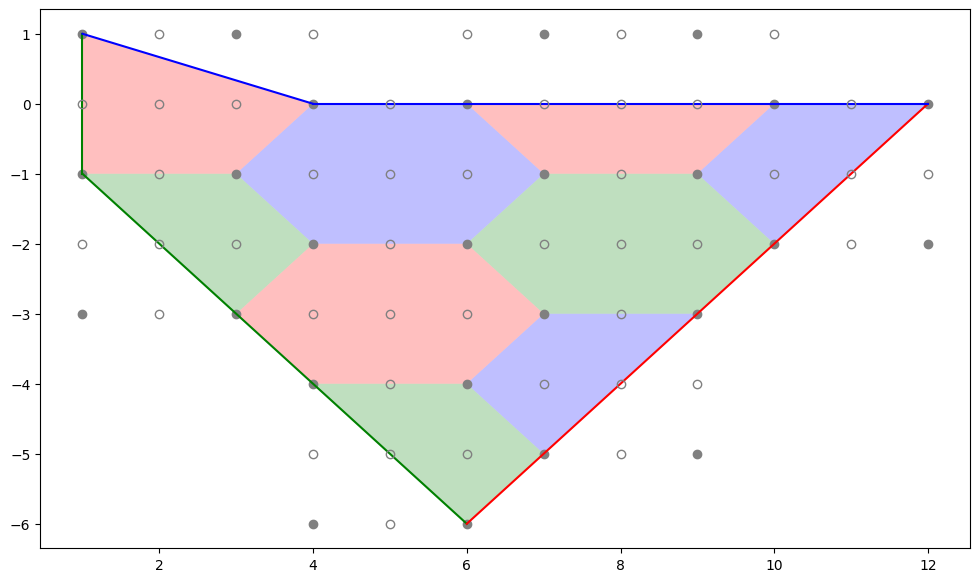

In [3]:
d = 5
qubit_dict, ancilla_dict, flag_qubit_coords, link_coords, boundary_qubit_coords, plaquettes = qubit_coord_groups(d)

draw_lattice(d,qubit_dict,ancilla_dict,plaquettes=plaquettes, qubit_label=False)

In [4]:
stim_circ = get_stim_circ_w_growing(d = 7,pipeline=False, measure_Clifford_on_data = True)
len(add_noise(stim_circ,CX_error=0.1).shortest_graphlike_error())

7

## Monte-Carlo sampling

In [5]:
num_shots = 10_000_000
shot_batch = 10_000

# d_list, err_list,LF_list,LF_errlist, yield_list = np.array([6]), np.array([3e-5,5e-5,1e-4,3e-4,5e-4,1e-3]), [], [], []
d_list, err_list = np.array([3]), np.array(range(1,2))*1e-3


result_dicts = {"d_list": d_list, "err_list": err_list}
for d in d_list:
    stim_circ0 = get_stim_circ_w_growing(d,basis="Y",pipeline=True)
    LF_list,LF_errlist, yield_list = [], [], []
    for err in err_list:
        stim_circ = add_noise(stim_circ0,
                            CX_error=err,
                            meas_error=err,
                            single_qubit_error=err,
                            gate_idle_error=err)

        log_fail = 0
        ps_shots = 0
        num_shots2 = 0
        sum_arr = np.ones((stim_circ.num_detectors),dtype=int)
        while num_shots2<num_shots and log_fail<=20*np.sqrt(log_fail):
            num_shots2+=shot_batch
            samples = stim_circ.compile_detector_sampler().sample(shot_batch,append_observables=True) 
            sums = sum_arr@samples.T[:-1]
            perfect_sample_mask = 1*(sums==0)
            log_fail += perfect_sample_mask@(samples.T[-1:][0])
            ps_shots += perfect_sample_mask@perfect_sample_mask
            if (num_shots2*20)%num_shots==0:
                print(".",end="")
        print()

        yield_list+=[ps_shots/num_shots2]
        LF_list+=[log_fail/ps_shots]
        LF_errlist+=[np.sqrt(log_fail+0.5)/ps_shots]
        print("d =",len(stim_circ.shortest_graphlike_error()),"   p =",err,"   PL =",log_fail/ps_shots,"+/-",np.sqrt(log_fail+0.5)/ps_shots,"   yield =", ps_shots/num_shots2)
    result_dicts[d]={"LF_list": LF_list,"LF_errlist":LF_errlist,"yield": yield_list}

....................
d = 3    p = 0.001    PL = 6.508806415079603e-07 +/- 4.058953933677369e-07    yield = 0.460914


In [5]:
with open('yield_comparison/GaugingClifford_high_dist_yield_nopipeline.pkl','rb') as f:
    result_dicts_gauging = pickle.load(f)
with open('yield_comparison/Gidney_cultivation_high_dist_yield.pkl','rb') as f:
    result_dicts_cultivation = pickle.load(f)

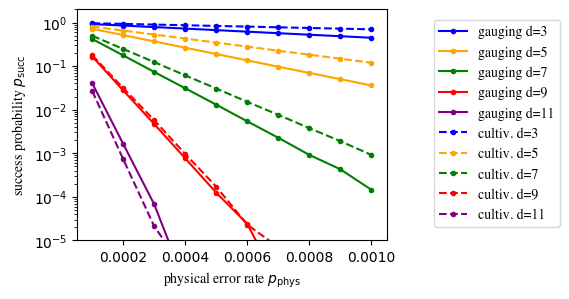

In [6]:
fig = plt.figure(figsize=(4,3))
colors = ['blue','orange','green','red','purple']
for d,c in zip(result_dicts_gauging['d_list'],colors):
    plt.plot(result_dicts_gauging['err_list'],result_dicts_gauging[d]['yield'],'.-',color=c,label="gauging d="+str(d))
for d,c in zip(result_dicts_gauging['d_list'],colors):
    plt.plot(result_dicts_cultivation['err_list'],result_dicts_cultivation[d]['yield'],'.--',color=c,label="cultiv. d="+str(d))
plt.yscale('log')
fig.legend(ncol = 1,bbox_to_anchor=(1.35, 0.5), loc='center right',prop={'family':'times'})
plt.xlim(5e-5,1.05e-3)
plt.ylim(1e-5,2)
plt.xlabel(r'physical error rate $p_\text{phys}$',fontfamily='times')
plt.ylabel(r'success probability $p_\text{succ}$',fontfamily='times')
plt.show()

## detector slice plots

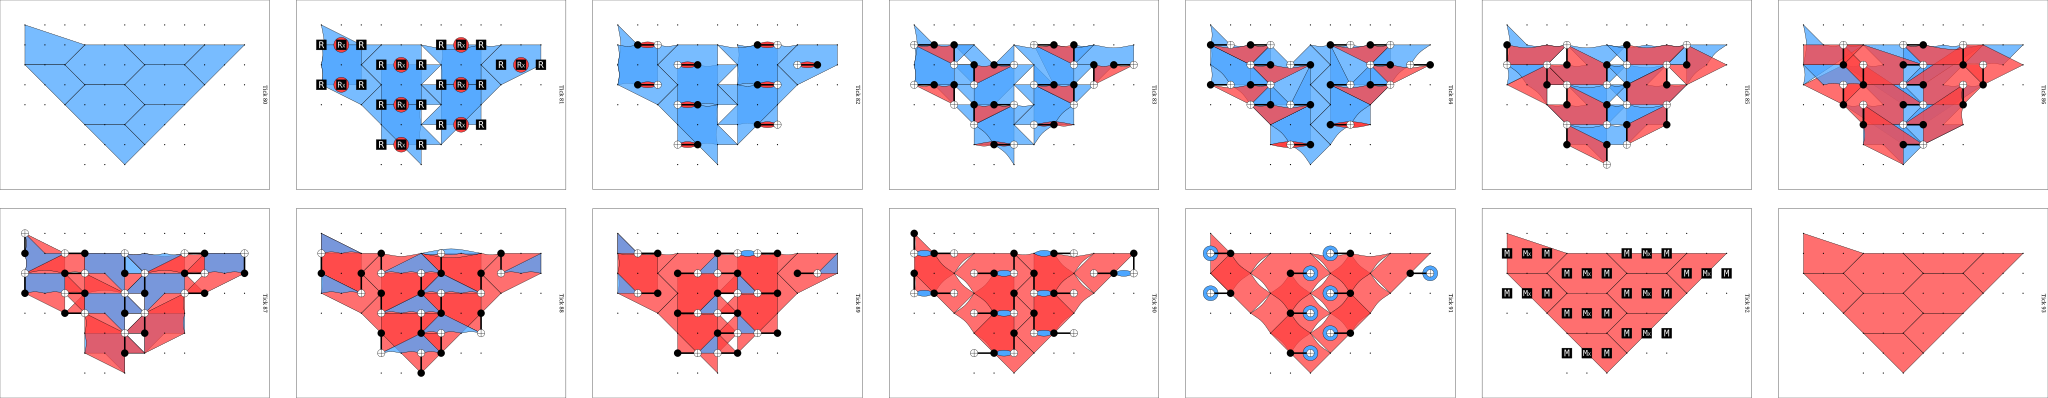

In [6]:
stim_circ = get_stim_circ_w_growing(5,extra_ticks=True,pipeline=False, measure_Clifford_on_data = True)

det_filter = [dc for dc in stim_circ.get_detector_coordinates().values() if len (dc)==3 and dc[0]==0 and dc[2]==2]+[dc for dc in stim_circ.get_detector_coordinates().values() if len (dc)==3 and dc[0]==1 and dc[2]==3]
fig = stim_circ.diagram('detslice-with-ops-svg',rows=2,tick=range(80,94),filter_coords=det_filter)
fig

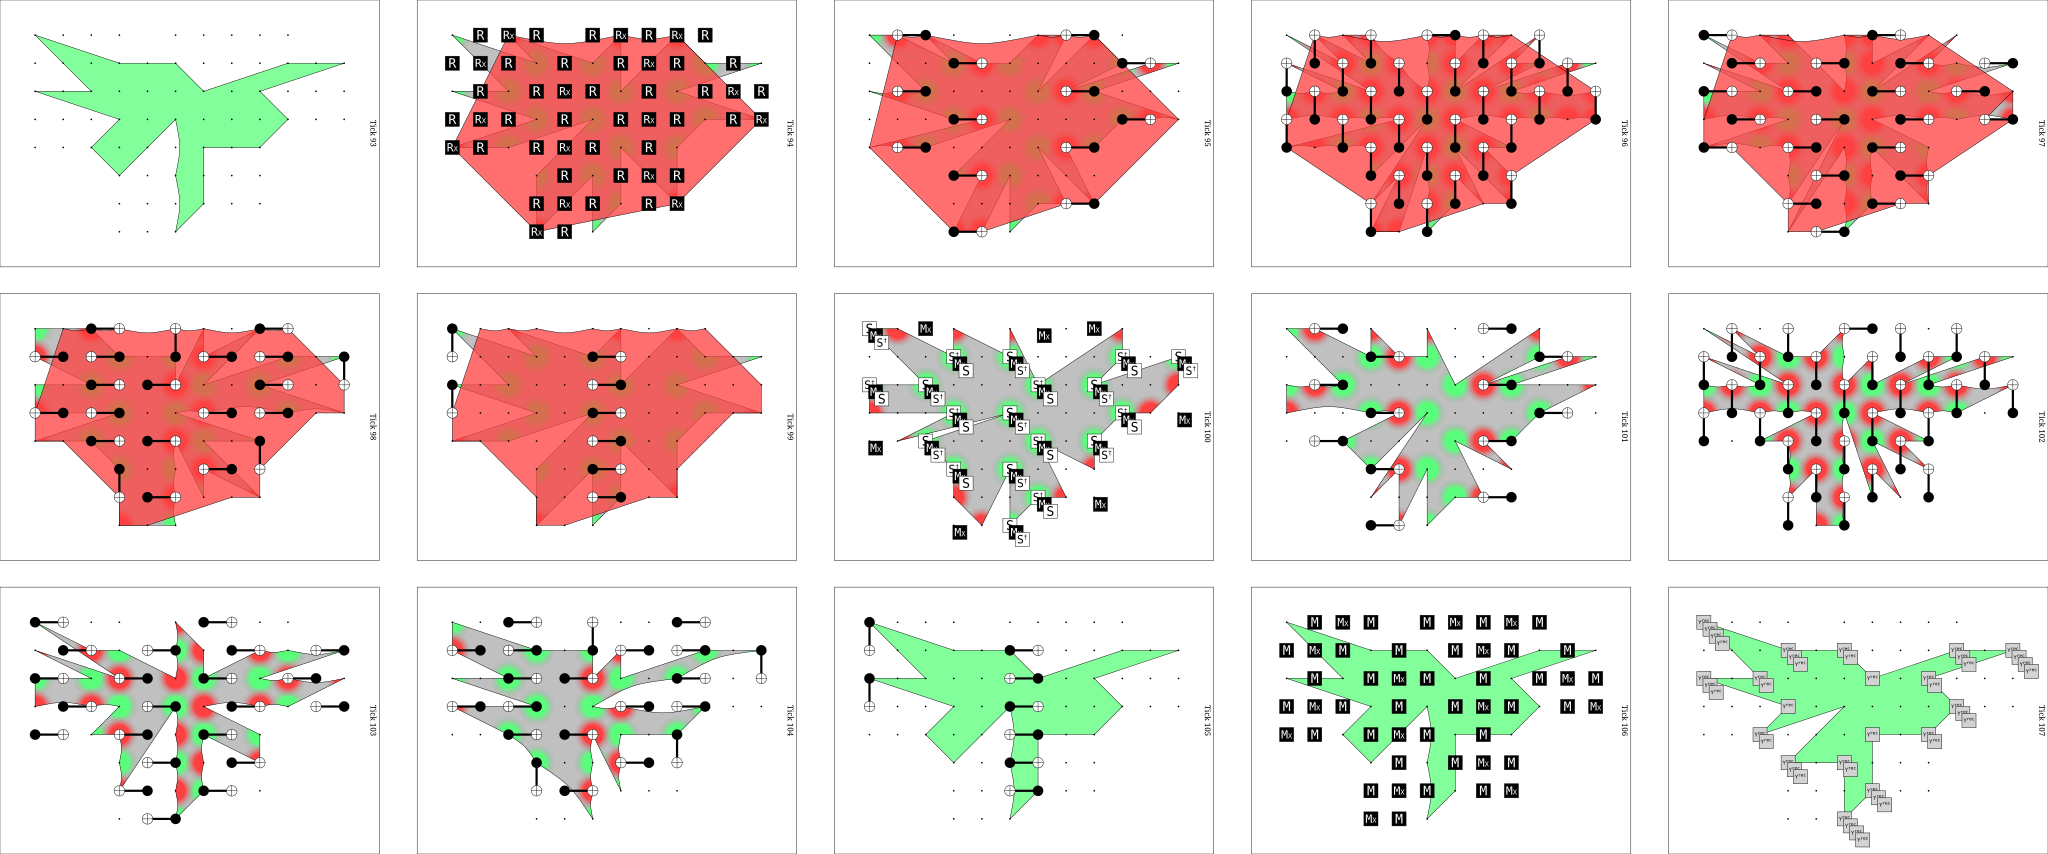

In [7]:
det_filter = [dc for dc in stim_circ.get_detector_coordinates().values() if dc==[-10,-10,-10] and len(dc)]
fig = stim_circ.diagram('detslice-with-ops-svg',rows=3,tick=range(93,108),filter_coords=det_filter)
fig

# Qiskit version of d=3

In [6]:
replace_S_with_T = True
num_shots = 10
shot_batch = 1

err_list = np.array([0.001])
# err_list = np.array([0.001,0.002,0.003,0.004,0.005])


stim_circ = get_stim_circ_d3_nofinalmeas(basis = "Y")
stim_circ = add_noise(stim_circ,
                    CX_error=0.1,
                    meas_error=0.1,
                    single_qubit_error=0.1,
                    gate_idle_error=0.1)

qc,dets,log=stim_to_qiskit(stim_circ,replace_S_with_T=replace_S_with_T)

lf_d = [0 for _ in range(len(err_list))]
ps_d = [0 for _ in range(len(err_list))]
num_shots2 = 0
result_dict = {}
while num_shots2<num_shots:
    num_shots2+=shot_batch
    for i,err in enumerate(err_list):
        data = Tstate_fidelity_sv(qc=qc,detectors=dets,log_obs=log,num_shots=shot_batch, prob_1 = err, prob_2 = err, prob_ro = err)
        ps_d[i] += data['ps_shots'][0]
        lf_d[i] += data['fail_sum']

        result_dict.update({"ps_shots_list":ps_d,"log_fail_list":lf_d})
result_dict

{'ps_shots_list': [0], 'log_fail_list': [0.0]}

# Cultivation (Gidney et al.)

In [8]:
num_shots = 1_000_000
shot_batch = 10_000

# d_list, err_list,LF_list,LF_errlist, yield_list = np.array([6]), np.array([3e-5,5e-5,1e-4,3e-4,5e-4,1e-3]), [], [], []
d_list, err_list = np.array([3]), np.array(range(1,2))*1e-3


result_dicts = {"d_list": d_list, "err_list": err_list}
for d in d_list:
    with open('cultivation_stim_circuits/noiseless_cultivation_circuit_d'+str(d)+'.stim','r') as f:
        stim_circ0 = stim.Circuit().from_file(f)
    LF_list,LF_errlist, yield_list = [], [], []
    for err in err_list:
        stim_circ = add_noise(stim_circ0,
                            CX_error=err,
                            meas_error=err,
                            single_qubit_error=err,
                            gate_idle_error=err)

        log_fail = 0
        ps_shots = 0
        num_shots2 = 0
        sum_arr = np.ones((stim_circ.num_detectors),dtype=int)
        while num_shots2<num_shots and log_fail<=20*np.sqrt(log_fail):
            num_shots2+=shot_batch
            samples = stim_circ.compile_detector_sampler().sample(shot_batch,append_observables=True) 
            sums = sum_arr@samples.T[:-1]
            perfect_sample_mask = 1*(sums==0)
            log_fail += perfect_sample_mask@(samples.T[-1:][0])
            ps_shots += perfect_sample_mask@perfect_sample_mask
            if (num_shots2*20)%num_shots==0:
                print(".",end="")
        print()

        yield_list+=[ps_shots/num_shots2]
        LF_list+=[log_fail/ps_shots]
        LF_errlist+=[np.sqrt(log_fail+0.5)/ps_shots]
        print("d =",len(stim_circ.shortest_graphlike_error()),"   p =",err,"   PL =",log_fail/ps_shots,"+/-",np.sqrt(log_fail+0.5)/ps_shots,"   yield =", ps_shots/num_shots2)
    result_dicts[d]={"LF_list": LF_list,"LF_errlist":LF_errlist,"yield": yield_list}

....................
d = 3    p = 0.001    PL = 0.0 +/- 1.0126813545633203e-06    yield = 0.698252


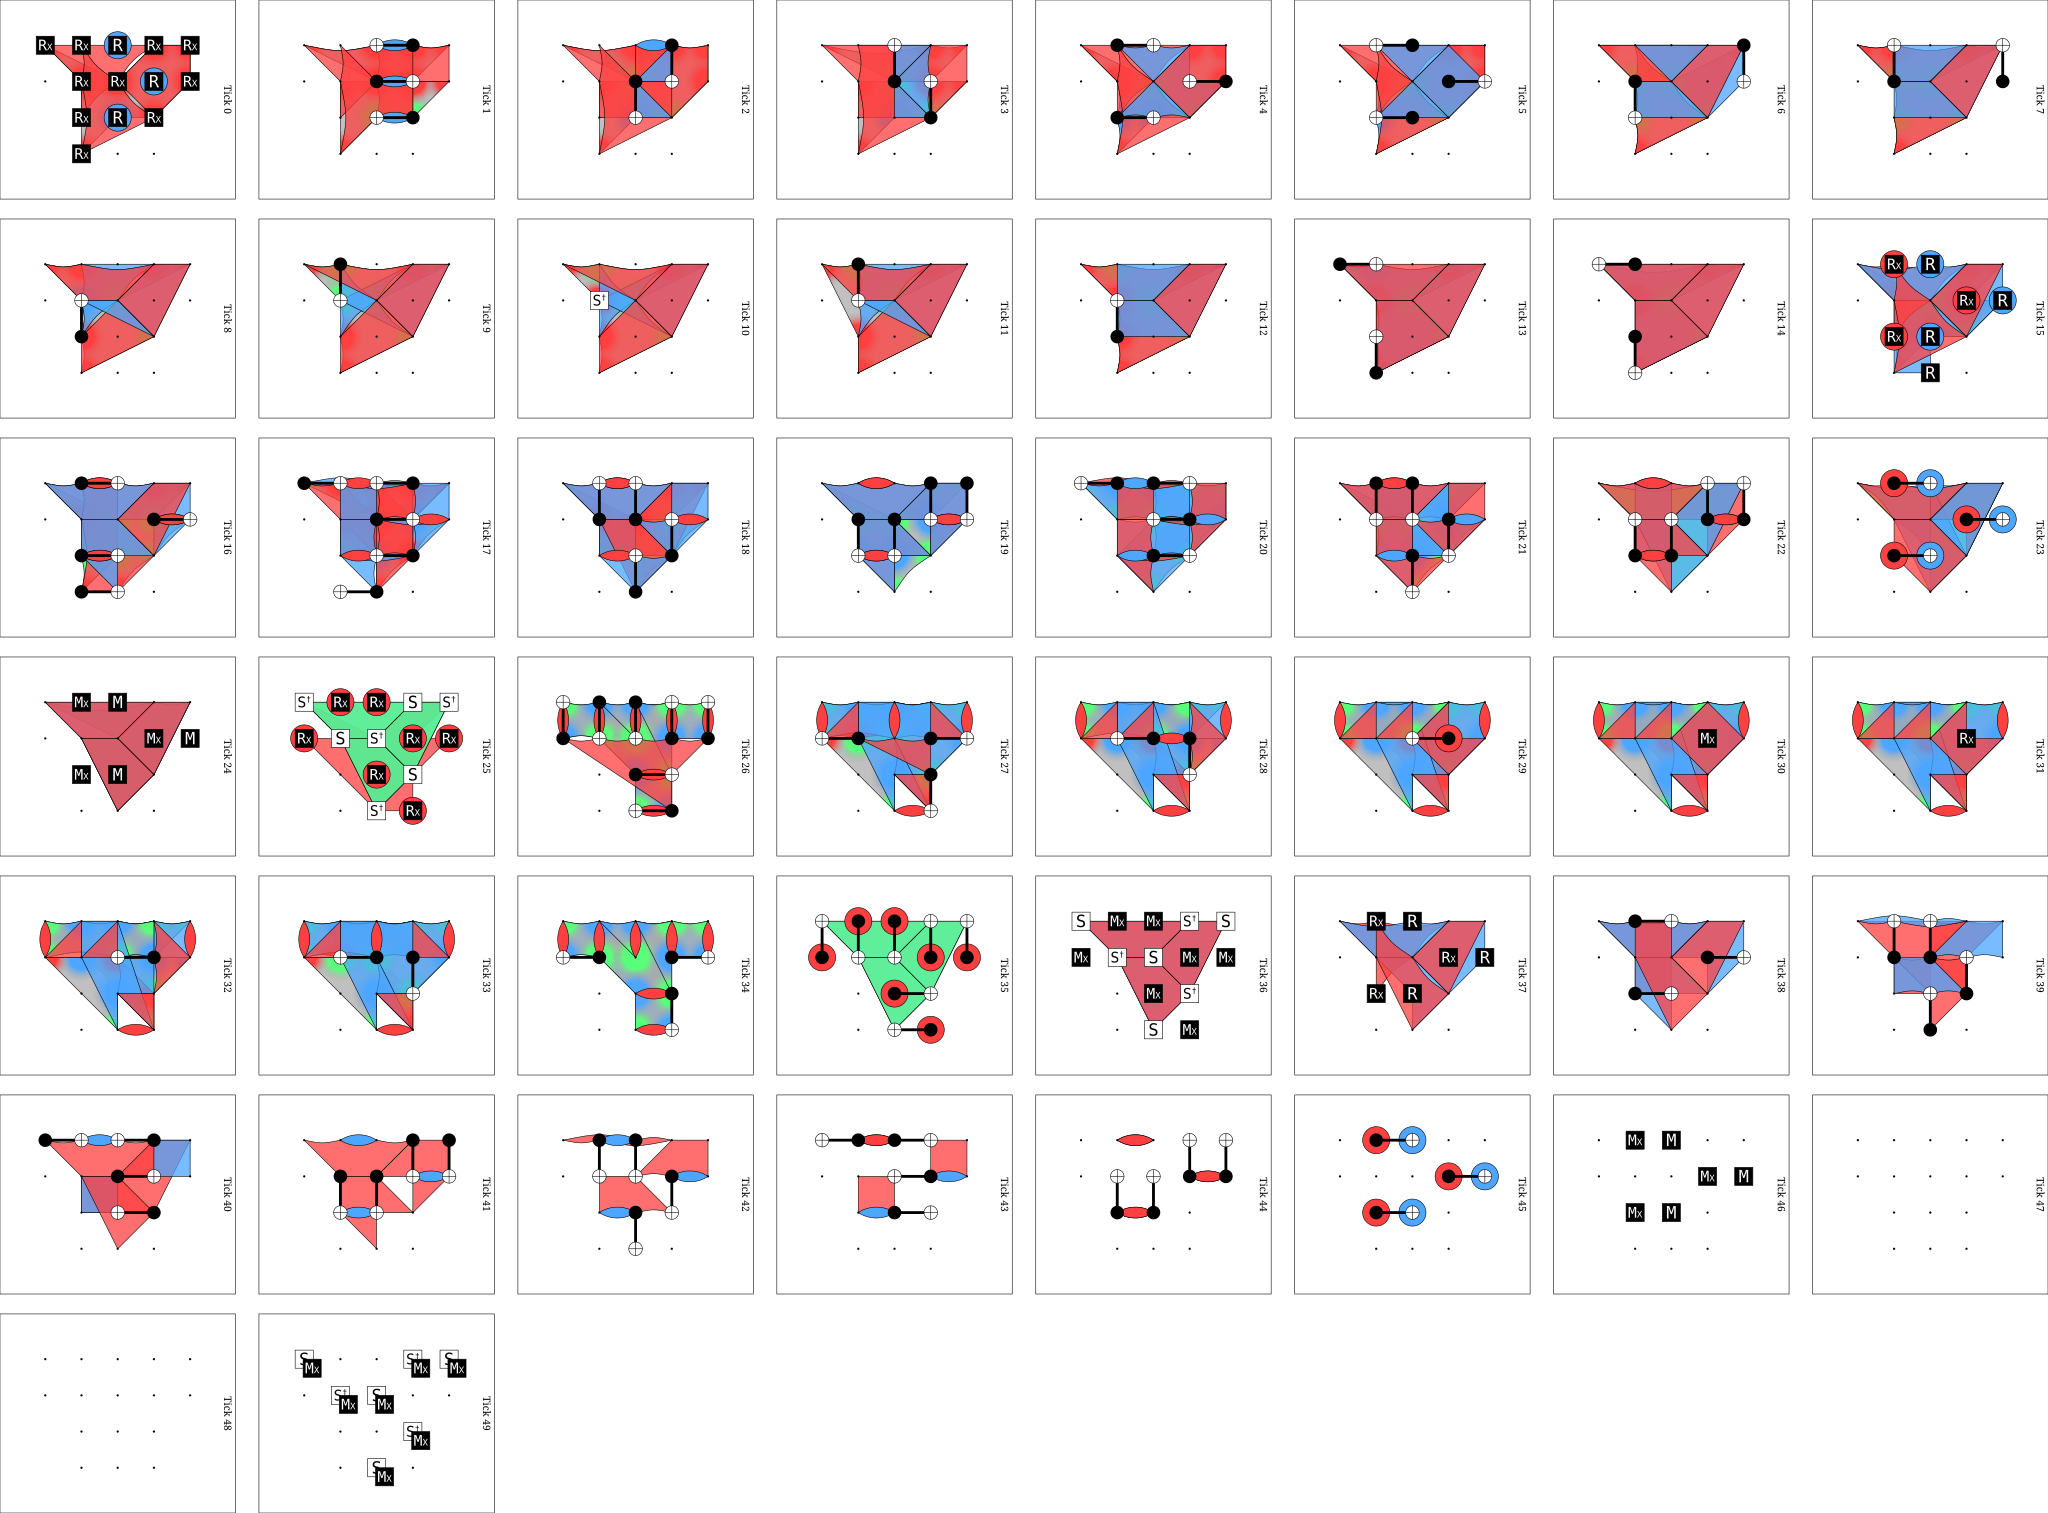

In [9]:
stim_circ0.diagram('detslice-with-ops-svg')

# Statevector vs Clifford simulations

In [10]:
# err_list: physical error rate for every operation including idles
# yield_list: logical error rate # post selected shots / # number of shots
# LF_list: logical error rate # logical failures / # post selected shots
# LFerr_list: logical error rate sqrt(# logical failures) / # post selected shots

Ystate_stim_d3 = {'err_list': np.array([0.001, 0.002, 0.003, 0.004, 0.005]),
                  'yield_list': np.array([0.46065795, 0.21261851, 0.09832248, 0.04558834, 0.02117186]),
                  'LF_list': np.array([8.90031313e-07, 7.61928018e-06, 3.03084300e-05, 6.97546785e-05,1.45948443e-04]),
                  'LF_errlist': np.array([1.39844528e-07, 5.99550283e-07, 1.75719251e-06, 3.91472212e-06, 8.30943152e-06])}

Ystate_qiskit_d3 = {'err_list': np.array([0.001, 0.002, 0.003, 0.004, 0.005]),
                    'yield_list': np.array([0.46073113, 0.21268602, 0.09834676, 0.04551968, 0.02113491]),
                    'LF_list': np.array([1.27983407e-06, 8.71338546e-06, 2.39828694e-05, 6.47697159e-05, 1.19570503e-04]),
                    'LF_errlist': np.array([4.83731812e-07, 1.85770002e-06, 4.53233629e-06, 1.09480802e-05, 2.18304872e-05])}

Tstate_qiskit_d3 = {'err_list': np.array([0.001, 0.002, 0.003, 0.004, 0.005]),
                    'yield_list': np.array([0.46065515, 0.21263031, 0.098486  , 0.04556521, 0.02117048]),
                    'LF_list': np.array([2.19152240e-07, 8.07133924e-06, 2.35762749e-05, 6.20363888e-05, 1.19215088e-04]),
                    'LF_errlist': np.array([2.19152240e-07, 1.95758731e-06, 4.91599314e-06, 1.17237755e-05, 2.38430176e-05])}

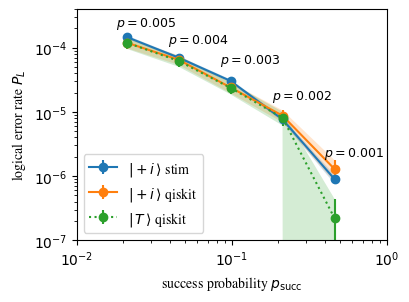

In [11]:
plt.figure(figsize=(4,3))
i=1
for res_dict,label,style in list(zip([Ystate_stim_d3,Ystate_qiskit_d3,Tstate_qiskit_d3],[r'$|+i\,\rangle$ stim',r'$|+i\,\rangle$ qiskit',r'$|\,T\,\rangle$ qiskit'],['-','-',":"]))[::]:
    # plt.plot(res_dict['yield_list'],res_dict['LF_list'],'o-',label=label)
    plt.errorbar(res_dict['yield_list'],res_dict['LF_list'],yerr=res_dict['LF_errlist'],label=label,marker = 'o',linestyle=style)
    plt.fill_between(res_dict['yield_list'],res_dict['LF_list']-res_dict['LF_errlist'],res_dict['LF_list']+res_dict['LF_errlist'],alpha = 0.2)
    if i:
        for physerr, yd, logerr in zip(res_dict['err_list'],res_dict['yield_list'],res_dict['LF_list']):
            plt.text(yd*.85, logerr*(2.5-200*physerr),r"$p="+str(physerr)+r"$",fontsize = 9,fontfamily='times')
        i=0

plt.loglog()
plt.legend(prop={'family':'times'})
plt.xlabel(r'success probability $p_\text{succ}$',fontsize=10,fontfamily='times')
plt.ylabel(r'logical error rate $P_L$',fontsize=10,fontfamily='times')
plt.xlim(1e-2,1)
plt.ylim(1e-7,4e-4)
plt.show()

# Escape stage

In [2]:
"""stabilizing first the grafted code, we achieve the code distance of the color code even with a noisy conversion step"""
d_cc, d_sc = 5,11
# d_cc, d_sc = 3,7
p=1e-3
basis = 'Y'
code = EscapeColorCode(d_cc, d_sc)

_, _, _, _, _, _, sc_plaquettes, _, _, grafted_Xplaquettes, grafted_Zplaquettes = qubit_coord_groups_escape(d_cc, d_sc)

code.grow_from_cc(basis=basis,measure_sc_plaquettes=True)
code.perfect_stab(Xstabs=[plaq for plaq in grafted_Xplaquettes],
                  Zstabs=[plaq for plaq in grafted_Zplaquettes])
for k,v in code.measurement_dict.copy().items():
    #bringing the color code plaquette measurements up in time
    if k[2]==0:
        if (k[0],k[1],code.time-1) not in code.measurement_dict:
            code.measurement_dict[(k[0],k[1],code.time-1)] = v
code.deform_to_sc(measure_sc_plaquettes=False)
code.perfect_stab(Xstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2],Zstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2==0])
code.noiseless_final_meas(basis=basis)


stim_circ = add_noise(code.circuit,CX_error=0.001,gate_idle_error=0.001)
truncate = 10
undet_errors = stim_circ.search_for_undetectable_logical_errors(dont_explore_detection_event_sets_with_size_above=truncate,
                                                                dont_explore_edges_with_degree_above=truncate,
                                                                dont_explore_edges_increasing_symptom_degree=True,
                                                                canonicalize_circuit_errors=True)
len(undet_errors),len(stim_circ.shortest_graphlike_error())

(5, 5)

In [3]:
"""Growing from color code in a single round with noisy operations everywhere. This reduces the code distance to two"""
d_cc, d_sc = 5,13
# d_cc, d_sc = 3,7
p=1e-3
basis = 'Z'
code = EscapeColorCode(d_cc, d_sc)

qubit_dict, ancilla_dict, flag_qubit_coords, _, _, cc_plaquettes, sc_plaquettes, _, _, grafted_Xplaquettes, grafted_Zplaquettes = qubit_coord_groups_escape(d_cc, d_sc)

# no errors in the state prep due to full PS
code.grow_from_cc(basis=basis,measure_sc_plaquettes=False)
code.deform_to_sc(measure_sc_plaquettes=True)
code.perfect_stab(Xstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2],Zstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2==0])
code.noiseless_final_meas(basis=basis,direct_grow=True)

stim_circ = add_noise(code.circuit,CX_error=0.001,gate_idle_error=0.001)
truncate = 10
undet_errors = stim_circ.search_for_undetectable_logical_errors(dont_explore_detection_event_sets_with_size_above=truncate,
                                                                dont_explore_edges_with_degree_above=truncate,
                                                                dont_explore_edges_increasing_symptom_degree=True,
                                                                canonicalize_circuit_errors=True)
len(undet_errors),len(stim_circ.shortest_graphlike_error())

(2, 2)

## gap decoding

In [4]:
from pymatching import Matching
dem = stim_circ.detector_error_model(decompose_errors=True,approximate_disjoint_errors=True,ignore_decomposition_failures=False)
m0 = Matching(dem)
logical_node = m0.num_nodes
m=Matching()
for i,edge in enumerate(m0.edges()):
    if edge[1]==None:
        if edge[2]['fault_ids']=={0}:
            # boundary + logical flip will be the new node
            m.add_edge(edge[0],logical_node,fault_ids={i},weight=edge[2]['weight'],error_probability=edge[2]['error_probability'])
        else:
            # boundary + no logical flip will remain the boundary
            m.add_boundary_edge(edge[0],fault_ids={i},weight=edge[2]['weight'],error_probability=edge[2]['error_probability'])
    else:
        m.add_edge(edge[0],edge[1],fault_ids={i},weight=edge[2]['weight'],error_probability=edge[2]['error_probability'])

samples = stim_circ.compile_detector_sampler().sample(shots=10_000, append_observables=True)
raw_logicals = samples[:,-1]
samples = samples[:,:-1]
comp_gap = []
log_flip = []
for sample in samples:
    corr_weight_log0 = sum(m.decode(sample.tolist()+[0]))
    corr_weight_log1 = sum(m.decode(sample.tolist()+[1]))
    comp_gap.append(abs(int(corr_weight_log0)-int(corr_weight_log1)))
    log_flip.append(1*(corr_weight_log0>corr_weight_log1))

In [5]:
for crit_gap in range(-1,len(stim_circ.shortest_graphlike_error())+1):
    log_fails = sum([pred!=raw for pred,raw in zip(log_flip,1*raw_logicals)])/len(log_flip)
    ps_out = [pred!=raw for pred,raw,gap in zip(log_flip,1*raw_logicals,comp_gap) if gap>crit_gap]
    ps_log_fails = sum(ps_out)/len(ps_out)
    print((crit_gap,ps_log_fails,log_fails,len(ps_out)/len(log_flip)))

(-1, np.float64(0.0216), np.float64(0.0216), 1.0)
(0, np.float64(0.016511345218800648), np.float64(0.0216), 0.9872)
(1, np.float64(0.008552014995313965), np.float64(0.0216), 0.8536)
(2, np.float64(0.0), np.float64(0.0216), 0.659)


## stabilizer group of the grafted code

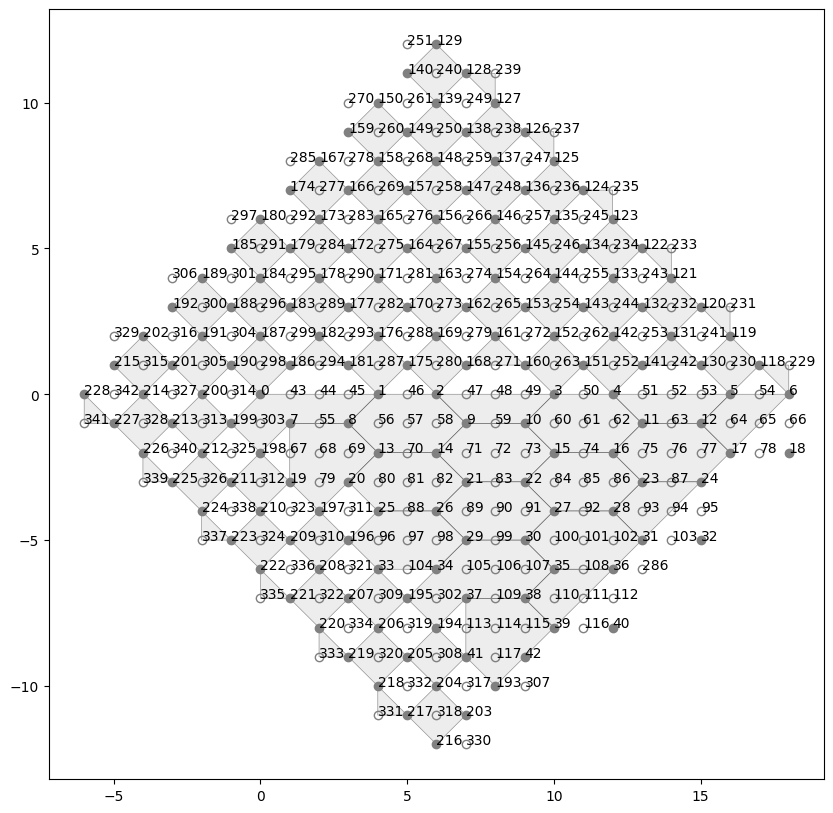

In [5]:
# d,d_sc = 3,7
# d,d_sc = 5,11
d,d_sc = 7,13
qubit_dict, ancilla_dict, flag_qubit_coords, link_coords, boundary_qubit_coords, plaquettes, sc_plaquettes, sc_log_X, sc_log_Z, grafted_Xplaquettes, grafted_Zplaquettes = qubit_coord_groups_escape(d,d_sc=d_sc)

# draw_lattice_escape(d,qubit_dict,ancilla_dict,plaquettes=plaquettes, X_plaquettes=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2], Z_plaquettes=[plaq for plaq in sc_plaquettes if not plaq['ancilla_coord'][0]%2], qubit_label=False,frame_on=True)
draw_lattice_escape(d,qubit_dict,ancilla_dict,plaquettes=[], X_plaquettes=grafted_Xplaquettes, Z_plaquettes=[], qubit_label=True,frame_on=True)
# draw_lattice_escape(d,qubit_dict,ancilla_dict,plaquettes=[], X_plaquettes=[], Z_plaquettes=grafted_Zplaquettes, qubit_label=False,frame_on=True)
# draw_lattice_escape(d,qubit_dict,ancilla_dict,plaquettes=[], X_plaquettes=grafted_Xplaquettes, Z_plaquettes=grafted_Zplaquettes, qubit_label=False,frame_on=True)

## figures for manuscript v1

In [13]:
d_cc, d_sc = 5,11
p=1e-3
basis = 'Z'
code = EscapeColorCode(d_cc, d_sc)

qubit_dict, ancilla_dict, flag_qubit_coords, _, _, cc_plaquettes, sc_plaquettes, _, _, grafted_Xplaquettes, grafted_Zplaquettes = qubit_coord_groups_escape(d_cc, d_sc)

if basis == 'X':
    code.circuit.append('H',[q for q in qubit_dict.values()])
code.perfect_stab(Xstabs=grafted_Xplaquettes,Zstabs=grafted_Zplaquettes)
code.circuit.append('DEPOLARIZE1',[q for q in qubit_dict.values() if q>code.d_cc**2],p)
code.deform_to_sc()
code.circuit.append('DEPOLARIZE1',[q for q in qubit_dict.values() if q>code.d_cc**2],p)
code.perfect_stab(Xstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2],Zstabs=[plaq for plaq in sc_plaquettes if plaq['ancilla_coord'][0]%2==0])
code.noiseless_final_meas(basis=basis)

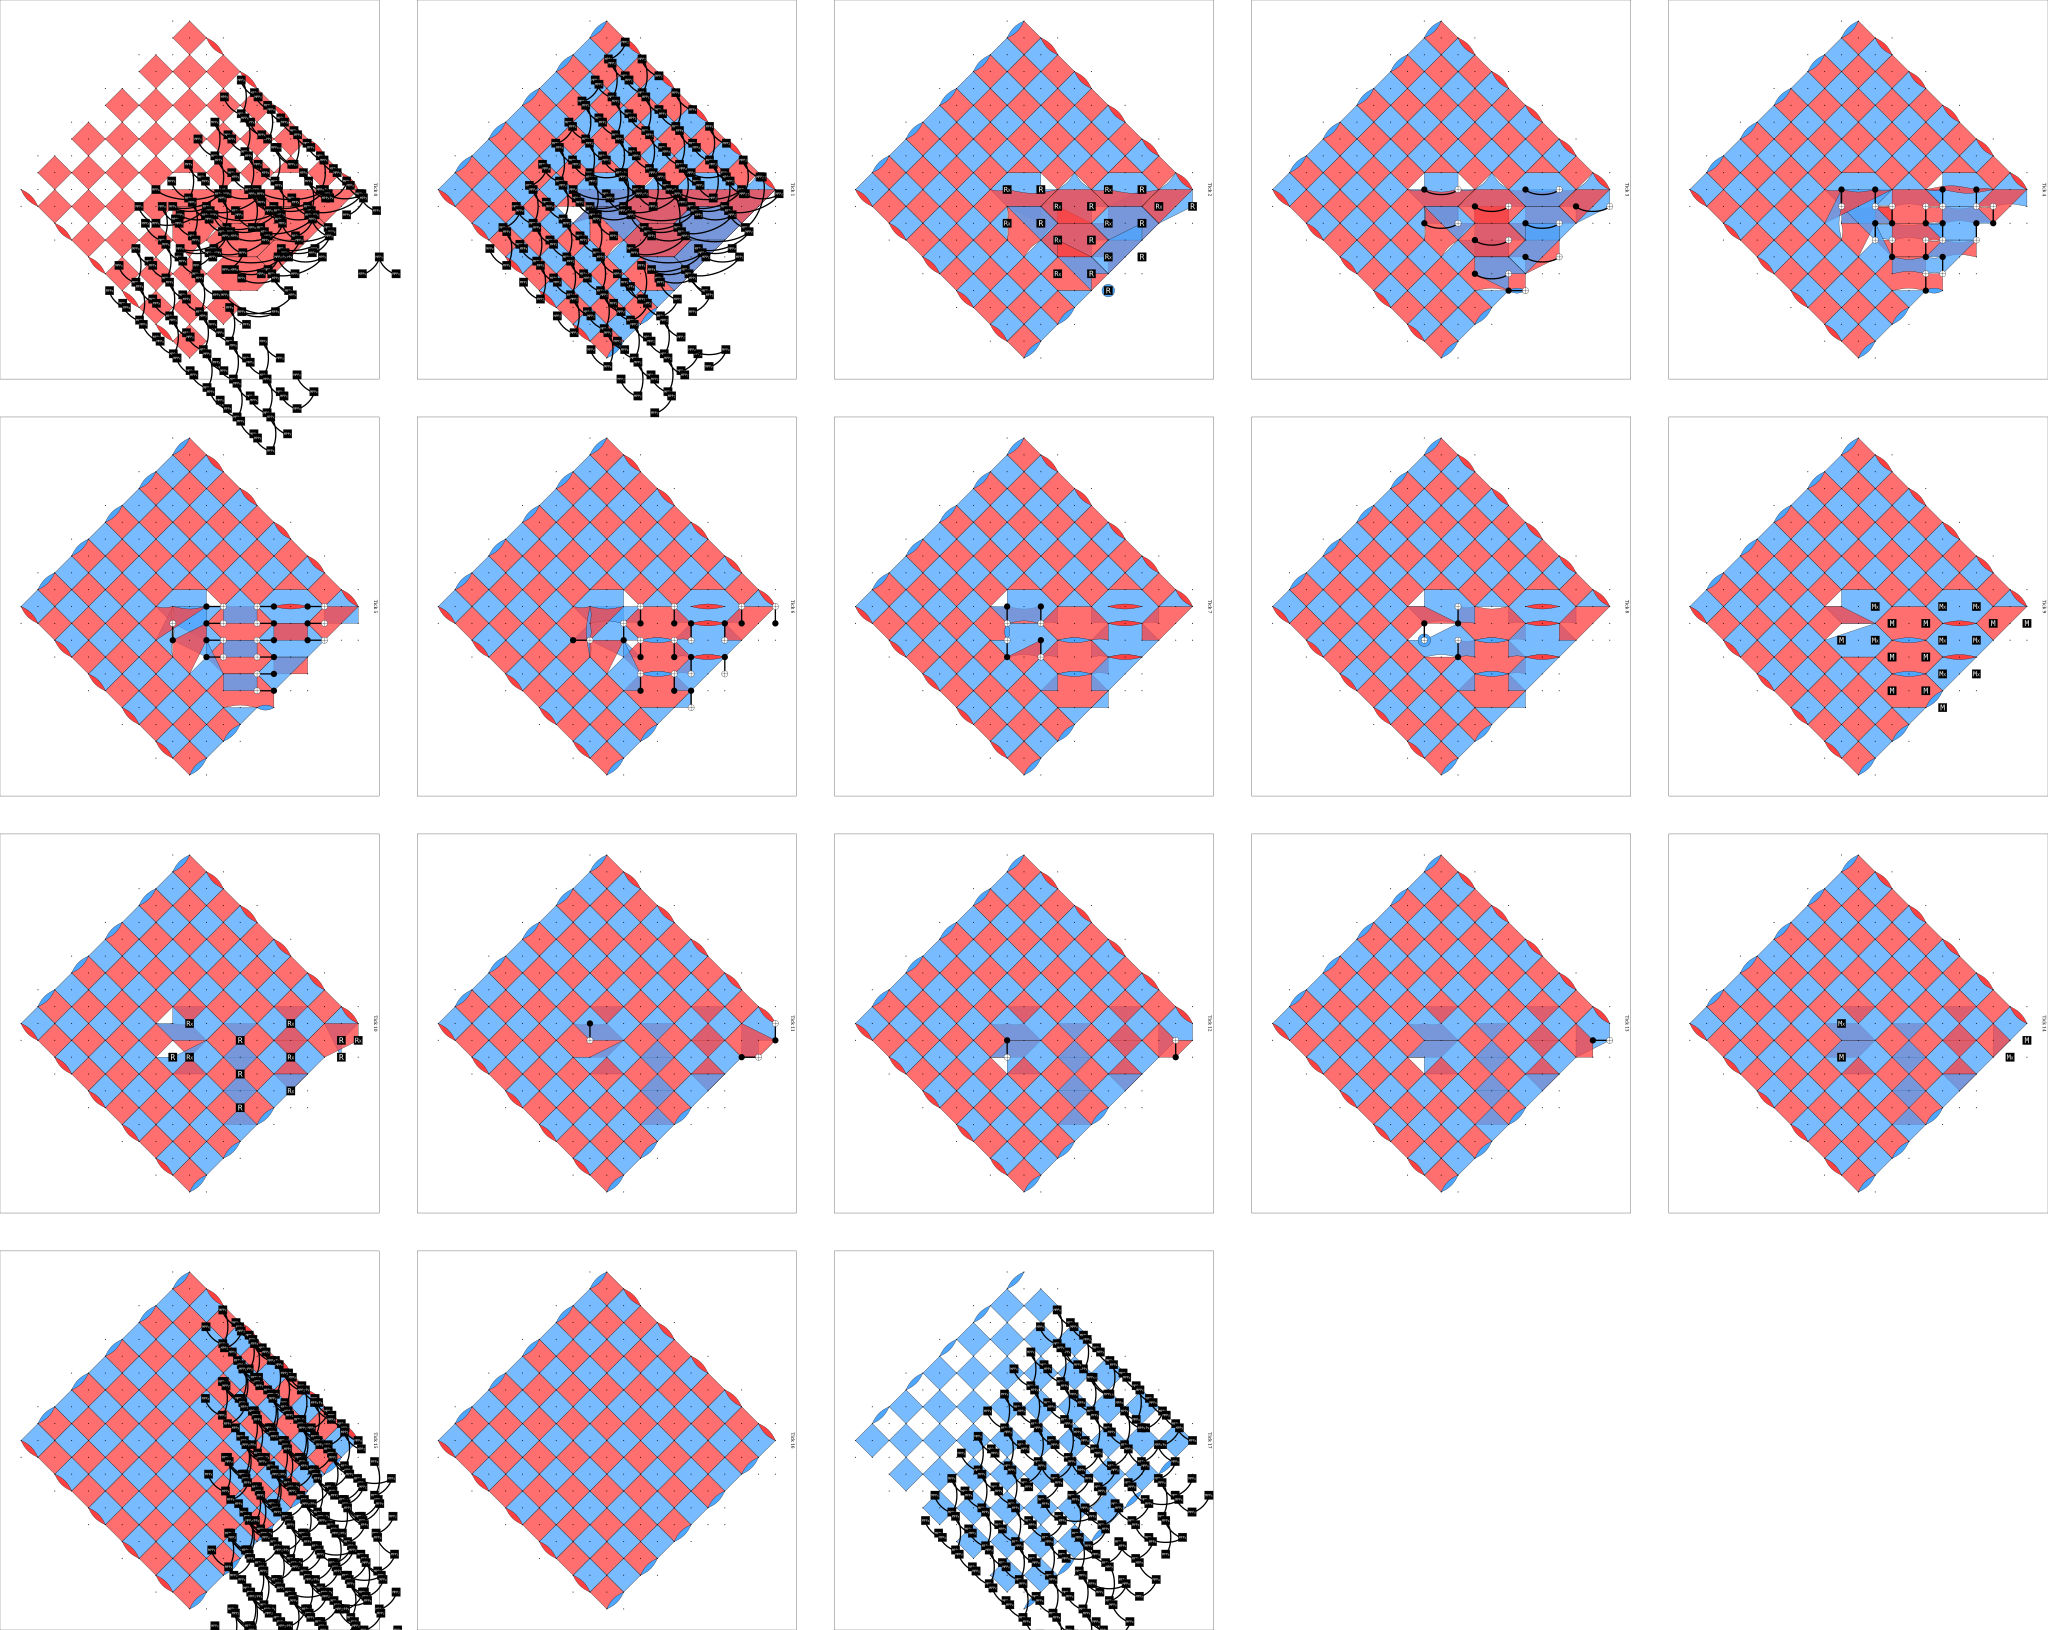

In [14]:
fig = code.circuit.without_noise().diagram('detslice-with-ops-svg',tick=range(0,18),rows=4)
fig

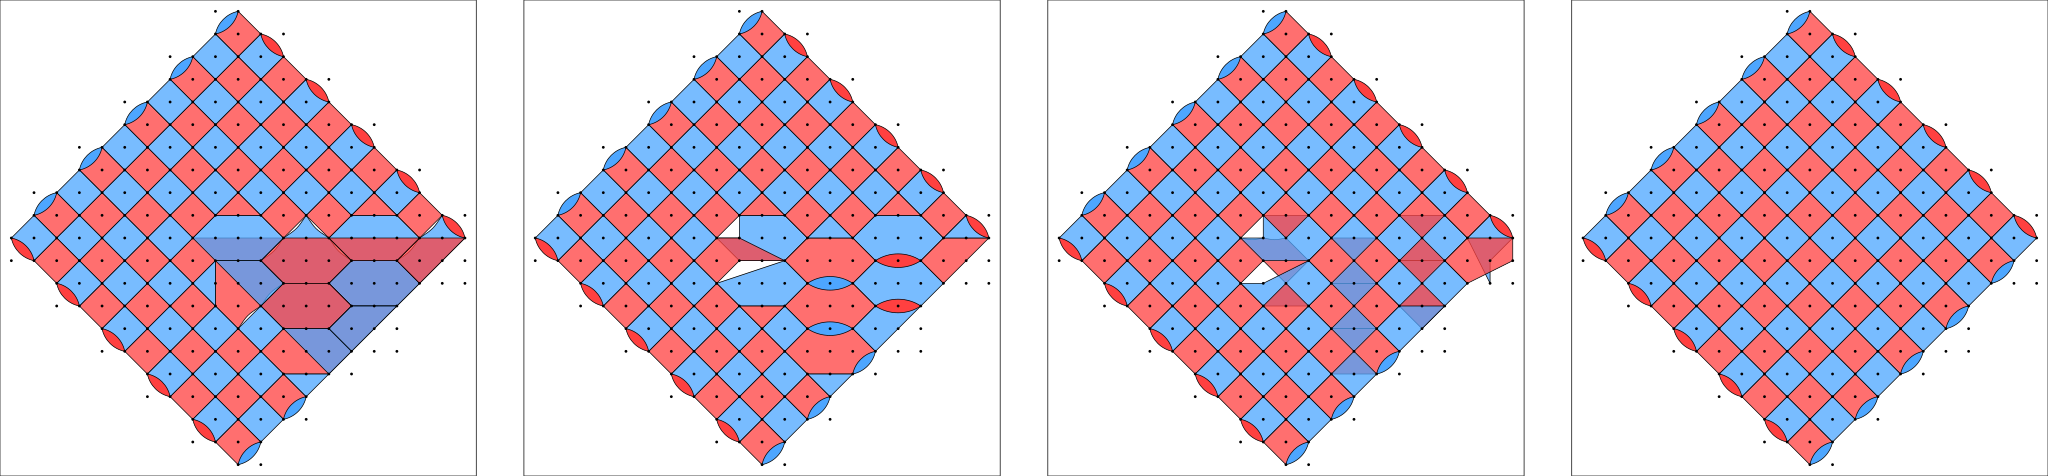

In [15]:
stim_circ2 = stim.Circuit()
tick_list = [1,9,10,15,16]
tick_count = 0
for inst in code.circuit:
    if inst.name=="TICK":
        tick_count+=1
        if tick_count-1 in tick_list:
            stim_circ2.append(inst)
    else:
        stim_circ2.append(inst)
fig = stim_circ2.diagram('detslice-svg',tick=range(1,5),rows=1)
fig